# AM01 Results Analysis Notebook

Notebook Colab per analizzare e visualizzare i risultati già salvati in Google Drive sotto `MyDrive/AM01/results`.

Questo notebook non addestra modelli. Legge metriche, score, history, split summary e file di audit; genera tabelle, grafici e artefatti utili per report/presentazione.

## 1. Setup

Modifica `RESULTS_ROOT` solo se hai salvato i risultati in una cartella diversa.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import auc, precision_recall_curve, roc_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RESULTS_ROOT = Path('/content/drive/MyDrive/AM01/results')
DRIVE_ROOT = RESULTS_ROOT.parent
ANALYSIS_DIR = RESULTS_ROOT / 'analysis'
FIGURES_DIR = ANALYSIS_DIR / 'figures'
TABLES_DIR = ANALYSIS_DIR / 'tables'
for path in [ANALYSIS_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    'isolation_forest': 'Isolation Forest',
    'ae_mlp': 'AE MLP',
    'ae_conv1d': 'AE Conv1D',
    'aae_mlp': 'AAE MLP',
    'pca': 'PCA',
}
MODEL_ORDER = ['isolation_forest', 'ae_mlp', 'ae_conv1d', 'aae_mlp', 'pca']

print('RESULTS_ROOT:', RESULTS_ROOT)
print('ANALYSIS_DIR:', ANALYSIS_DIR)

RESULTS_ROOT: /content/drive/MyDrive/AM01/results
ANALYSIS_DIR: /content/drive/MyDrive/AM01/results/analysis


## 2. Utility di caricamento

Il notebook cerca automaticamente run directory che contengono `metrics.json`.

In [3]:
def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def find_run_dirs(results_root: Path) -> list[Path]:
    preferred = results_root / 'runs' / 'main'
    if preferred.exists():
        dirs = sorted([p for p in preferred.iterdir() if (p / 'metrics.json').exists()])
        if dirs:
            return dirs
    return sorted({p.parent for p in results_root.rglob('metrics.json')})


def model_key_from_dir(run_dir: Path) -> str:
    name = run_dir.name
    if name in MODEL_LABELS:
        return name
    for key in sorted(MODEL_LABELS, key=len, reverse=True):
        if key in name:
            return key
    return name


def model_label(model_key: str) -> str:
    return MODEL_LABELS.get(model_key, model_key)


run_dirs = find_run_dirs(RESULTS_ROOT)
if not run_dirs:
    raise FileNotFoundError(f'Nessun metrics.json trovato sotto {RESULTS_ROOT}')

display(pd.DataFrame({'run_dir': [str(p) for p in run_dirs], 'model_key': [model_key_from_dir(p) for p in run_dirs]}))

,run_dir,model_key
0,/content/drive/MyDrive/AM01/results/runs/main/...,aae_mlp
1,/content/drive/MyDrive/AM01/results/runs/main/...,ae_conv1d
2,/content/drive/MyDrive/AM01/results/runs/main/...,ae_mlp
3,/content/drive/MyDrive/AM01/results/runs/main/...,isolation_forest
4,/content/drive/MyDrive/AM01/results/runs/main/pca,pca


## 3. Tabella metrica principale

Questa tabella è la base quantitativa del confronto. Verrà salvata anche in Drive.

In [4]:
def load_metrics_table(run_dirs: list[Path]) -> pd.DataFrame:
    rows = []
    for run_dir in run_dirs:
        metrics = read_json(run_dir / 'metrics.json')
        key = model_key_from_dir(run_dir)
        row = {
            'run_name': run_dir.name,
            'run_dir': str(run_dir),
            'model_key': key,
            'model': model_label(key),
            'threshold': metrics.get('threshold'),
        }
        for split_name in ['validation_metrics', 'test_metrics']:
            prefix = 'val' if split_name.startswith('validation') else 'test'
            for metric, value in metrics.get(split_name, {}).items():
                row[f'{prefix}_{metric}'] = value
        rows.append(row)
    df = pd.DataFrame(rows)
    df['order'] = df['model_key'].map({m: i for i, m in enumerate(MODEL_ORDER)}).fillna(999)
    return df.sort_values(['order', 'run_name']).drop(columns=['order']).reset_index(drop=True)


metrics_df = load_metrics_table(run_dirs)
metrics_df.to_csv(TABLES_DIR / 'metrics_all_models.csv', index=False)

summary_cols = [
    'model', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc', 'test_pr_auc',
    'test_event_recall', 'test_event_precision', 'test_false_positive_rate',
    'test_false_alarms_per_run', 'test_mean_detection_delay', 'test_fp', 'test_fn'
]
available_cols = [c for c in summary_cols if c in metrics_df.columns]
main_metrics = metrics_df[available_cols].copy()
main_metrics.to_csv(TABLES_DIR / 'main_metrics_compact.csv', index=False)
display(main_metrics.style.format(precision=3))

,model,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_event_recall,test_event_precision,test_false_positive_rate,test_false_alarms_per_run,test_mean_detection_delay,test_fp,test_fn
0,Isolation Forest,0.616,0.853,0.716,0.937,0.720,0.900,0.436,0.137,0.150,1.778,170.000,47.000
1,AE MLP,0.468,0.878,0.611,0.848,0.457,0.950,0.264,0.256,0.302,3.368,319.000,39.000
2,AE Conv1D,0.540,0.703,0.611,0.828,0.457,0.683,0.309,0.154,0.178,4.293,192.000,95.000
3,AAE MLP,0.441,0.847,0.580,0.827,0.444,0.883,0.235,0.277,0.340,3.321,344.000,49.000
4,PCA,0.303,0.559,0.393,0.688,0.287,0.900,0.227,0.330,0.446,7.407,411.000,141.000


## 4. Ranking modelli

Ordina i modelli per F1, PR-AUC, ROC-AUC, falsi allarmi e delay.

In [5]:
ranking_cols = ['model']
for col in ['test_f1', 'test_pr_auc', 'test_roc_auc', 'test_event_recall', 'test_event_precision', 'test_false_alarms_per_run', 'test_mean_detection_delay']:
    if col in metrics_df.columns:
        ranking_cols.append(col)

ranking = metrics_df[ranking_cols].copy()
if 'test_f1' in ranking:
    ranking = ranking.sort_values('test_f1', ascending=False)
ranking.to_csv(TABLES_DIR / 'model_ranking.csv', index=False)
display(ranking.style.format(precision=3))

def best_model(metric: str, higher_is_better: bool = True):
    if metric not in metrics_df.columns:
        return None
    idx = metrics_df[metric].idxmax() if higher_is_better else metrics_df[metric].idxmin()
    return metrics_df.loc[idx, ['model', metric]]

for metric, hib in [('test_f1', True), ('test_pr_auc', True), ('test_roc_auc', True), ('test_false_alarms_per_run', False), ('test_mean_detection_delay', False)]:
    item = best_model(metric, hib)
    if item is not None:
        display(Markdown(f"**Best {metric}:** {item['model']} = {item[metric]:.3f}"))

,model,test_f1,test_pr_auc,test_roc_auc,test_event_recall,test_event_precision,test_false_alarms_per_run,test_mean_detection_delay
0,Isolation Forest,0.716,0.720,0.937,0.900,0.436,0.150,1.778
1,AE MLP,0.611,0.457,0.848,0.950,0.264,0.302,3.368
2,AE Conv1D,0.611,0.457,0.828,0.683,0.309,0.178,4.293
3,AAE MLP,0.580,0.444,0.827,0.883,0.235,0.340,3.321
4,PCA,0.393,0.287,0.688,0.900,0.227,0.446,7.407


**Best test_f1:** Isolation Forest = 0.716

**Best test_pr_auc:** Isolation Forest = 0.720

**Best test_roc_auc:** Isolation Forest = 0.937

**Best test_false_alarms_per_run:** Isolation Forest = 0.150

**Best test_mean_detection_delay:** Isolation Forest = 1.778

## 5. Grafici metriche principali

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/bar_test_f1.png


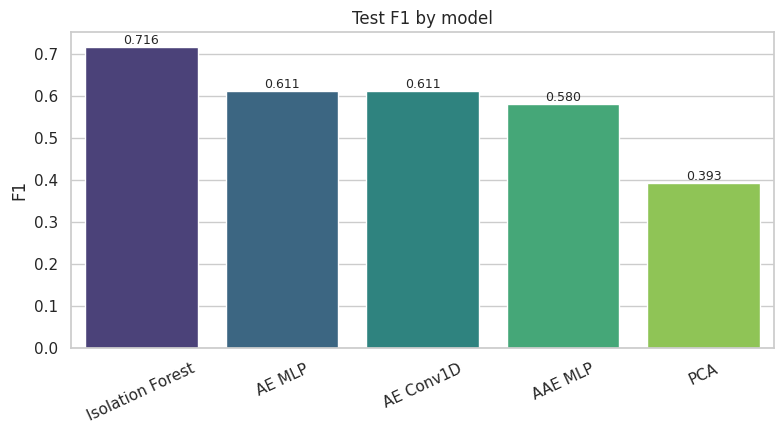

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/bar_test_pr_auc.png


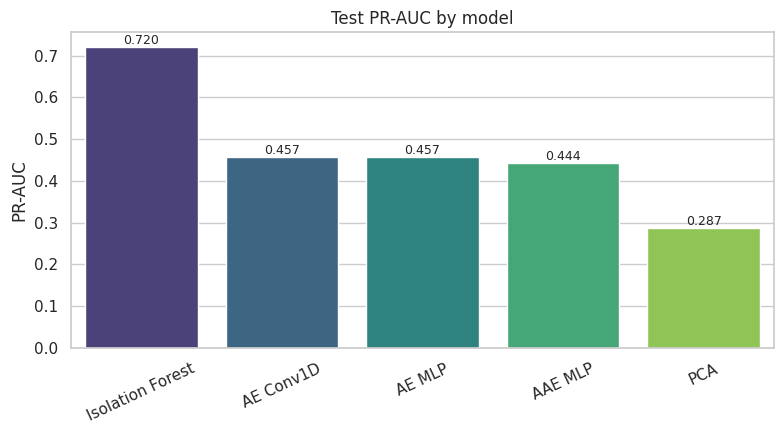

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/bar_test_roc_auc.png


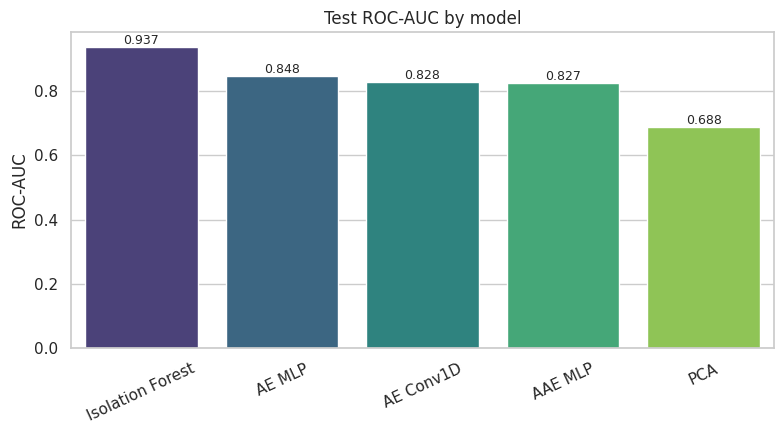

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/bar_test_false_alarms_per_run.png


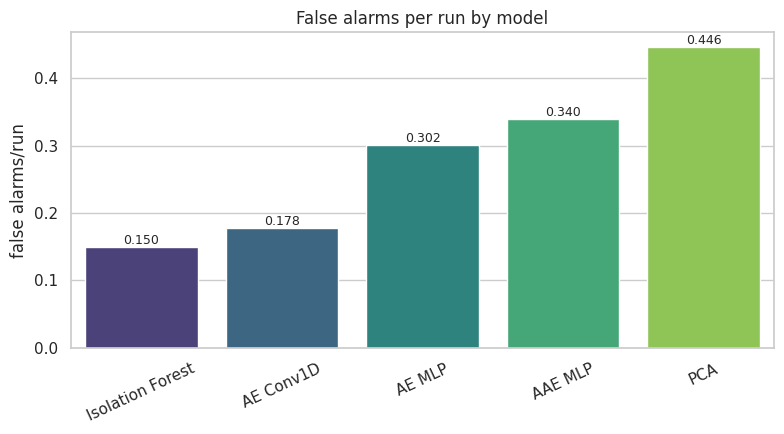

In [6]:
def save_current_fig(name: str):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:', path)


def barplot_metric(metric: str, title: str, ylabel: str | None = None, ascending: bool = False):
    if metric not in metrics_df.columns:
        print(f'Skip {metric}: colonna non presente')
        return
    data = metrics_df[['model', metric]].dropna().sort_values(metric, ascending=ascending)
    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(data=data, x='model', y=metric, palette='viridis')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel or metric)
    ax.tick_params(axis='x', rotation=25)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    save_current_fig(f'bar_{metric}.png')
    plt.show()


barplot_metric('test_f1', 'Test F1 by model', 'F1')
barplot_metric('test_pr_auc', 'Test PR-AUC by model', 'PR-AUC')
barplot_metric('test_roc_auc', 'Test ROC-AUC by model', 'ROC-AUC')
barplot_metric('test_false_alarms_per_run', 'False alarms per run by model', 'false alarms/run', ascending=True)

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/metric_profile_by_model.png


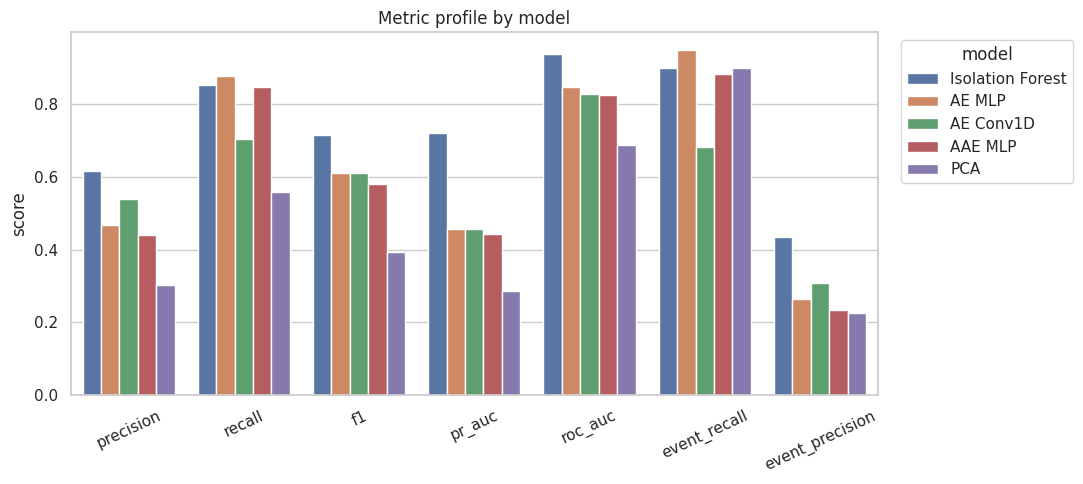

In [7]:
metrics_to_compare = [
    'test_precision', 'test_recall', 'test_f1', 'test_pr_auc', 'test_roc_auc',
    'test_event_recall', 'test_event_precision'
]
plot_cols = [c for c in metrics_to_compare if c in metrics_df.columns]
long_metrics = metrics_df[['model'] + plot_cols].melt(id_vars='model', var_name='metric', value_name='value')
long_metrics['metric'] = long_metrics['metric'].str.replace('test_', '', regex=False)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=long_metrics, x='metric', y='value', hue='model')
ax.set_title('Metric profile by model')
ax.set_xlabel('')
ax.set_ylabel('score')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='model', bbox_to_anchor=(1.02, 1), loc='upper left')
save_current_fig('metric_profile_by_model.png')
plt.show()

## 6. AE vs AAE: confronto diretto

Questa è la vista centrale per la research question.

,model,test_f1,test_pr_auc,test_roc_auc,test_precision,test_recall,test_event_recall,test_event_precision,test_false_alarms_per_run,test_mean_detection_delay
1,AE MLP,0.611,0.457,0.848,0.468,0.878,0.950,0.264,0.302,3.368
3,AAE MLP,0.580,0.444,0.827,0.441,0.847,0.883,0.235,0.340,3.321


,metric,AAE_minus_AE
0,f1,-0.0312
1,pr_auc,-0.0133
2,roc_auc,-0.0216
3,precision,-0.0277
4,recall,-0.0312
5,event_recall,-0.0667
6,event_precision,-0.0288
7,false_alarms_per_run,0.0380
8,mean_detection_delay,-0.0477


Saved: /content/drive/MyDrive/AM01/results/analysis/figures/aae_minus_ae_deltas.png


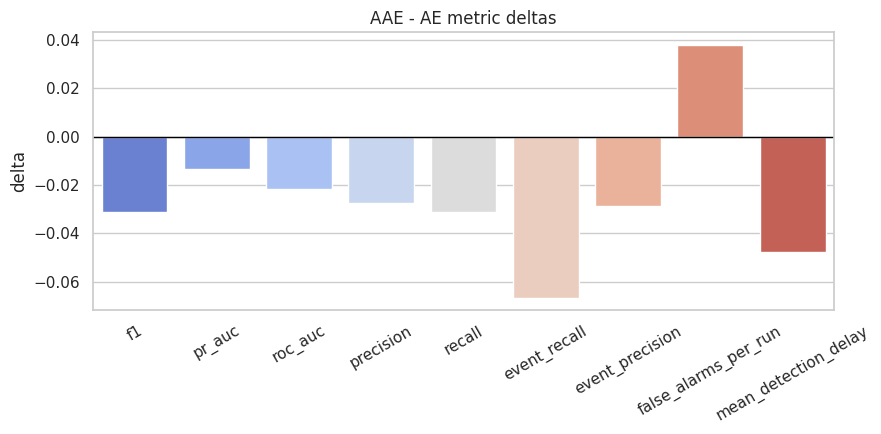

In [8]:
ae_rows = metrics_df[metrics_df['model_key'].isin(['ae_mlp', 'aae_mlp'])].copy()
ae_compare_cols = ['model', 'test_f1', 'test_pr_auc', 'test_roc_auc', 'test_precision', 'test_recall', 'test_event_recall', 'test_event_precision', 'test_false_alarms_per_run', 'test_mean_detection_delay']
ae_compare_cols = [c for c in ae_compare_cols if c in ae_rows.columns]
display(ae_rows[ae_compare_cols].style.format(precision=3))

if set(['ae_mlp', 'aae_mlp']).issubset(set(ae_rows['model_key'])):
    ae = ae_rows[ae_rows['model_key'] == 'ae_mlp'].iloc[0]
    aae = ae_rows[ae_rows['model_key'] == 'aae_mlp'].iloc[0]
    deltas = []
    for metric in [c for c in ae_compare_cols if c != 'model']:
        deltas.append({'metric': metric.replace('test_', ''), 'AAE_minus_AE': aae[metric] - ae[metric]})
    deltas_df = pd.DataFrame(deltas)
    deltas_df.to_csv(TABLES_DIR / 'aae_minus_ae_deltas.csv', index=False)
    display(deltas_df.style.format({'AAE_minus_AE': '{:.4f}'}))

    plt.figure(figsize=(9, 4.5))
    ax = sns.barplot(data=deltas_df, x='metric', y='AAE_minus_AE', palette='coolwarm')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title('AAE - AE metric deltas')
    ax.set_xlabel('')
    ax.set_ylabel('delta')
    ax.tick_params(axis='x', rotation=30)
    save_current_fig('aae_minus_ae_deltas.png')
    plt.show()
else:
    print('AE MLP e/o AAE MLP non trovati nei risultati.')

## 7. Caricamento score validation/test

Gli score permettono curve ROC/PR, distribuzioni, timeline e analisi dei falsi positivi.

In [9]:
def load_scores(run_dirs: list[Path]) -> dict[str, dict[str, pd.DataFrame]]:
    out = {}
    for run_dir in run_dirs:
        key = model_key_from_dir(run_dir)
        out[key] = {}
        threshold = read_json(run_dir / 'metrics.json').get('threshold')
        for split in ['val', 'test']:
            path = run_dir / f'scores_{split}.csv'
            if not path.exists():
                continue
            frame = pd.read_csv(path)
            frame['model_key'] = key
            frame['model'] = model_label(key)
            frame['split'] = split
            frame['threshold'] = threshold
            if 'label' in frame.columns:
                frame['pred'] = (frame['score'] >= threshold).astype(int)
                frame['error_type'] = np.select(
                    [
                        (frame['label'] == 0) & (frame['pred'] == 0),
                        (frame['label'] == 0) & (frame['pred'] == 1),
                        (frame['label'] == 1) & (frame['pred'] == 0),
                        (frame['label'] == 1) & (frame['pred'] == 1),
                    ],
                    ['TN', 'FP', 'FN', 'TP'],
                    default='unknown',
                )
            out[key][split] = frame
    return out


scores = load_scores(run_dirs)
test_scores_all = pd.concat([splits['test'] for splits in scores.values() if 'test' in splits], ignore_index=True)
test_scores_all.to_csv(TABLES_DIR / 'all_test_scores_with_predictions.csv', index=False)
display(test_scores_all.head())
print(test_scores_all.groupby(['model', 'error_type']).size().unstack(fill_value=0) if 'error_type' in test_scores_all else 'No labels')

,run_id,start,score,label,model_key,model,split,threshold,pred,error_type
0,normal_seg_0003,0,0.277630,0,aae_mlp,AAE MLP,test,0.330609,0,TN
1,normal_seg_0003,16,0.286650,0,aae_mlp,AAE MLP,test,0.330609,0,TN
2,normal_seg_0003,32,0.258312,0,aae_mlp,AAE MLP,test,0.330609,0,TN
3,normal_seg_0005,0,0.265215,0,aae_mlp,AAE MLP,test,0.330609,0,TN
4,normal_seg_0005,16,0.282265,0,aae_mlp,AAE MLP,test,0.330609,0,TN


error_type         FN   FP    TN   TP
model                                
AAE MLP            49  344   900  271
AE Conv1D          95  192  1052  225
AE MLP             39  319   925  281
Isolation Forest   47  170  1074  273
PCA               141  411   833  179


## 8. Distribuzioni degli anomaly score

Usiamo `log1p(score)` perché alcuni modelli possono avere outlier molto grandi.

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/test_score_distribution_violin.png


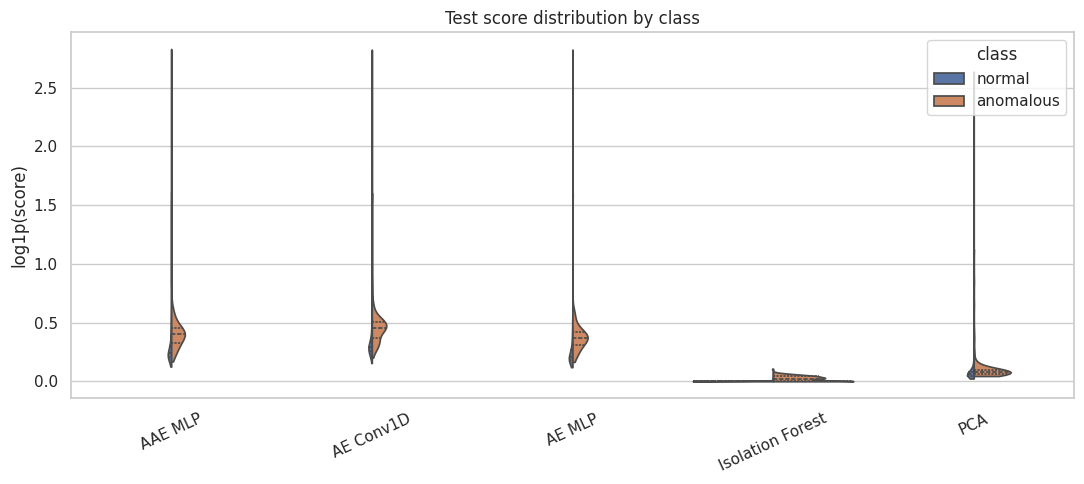

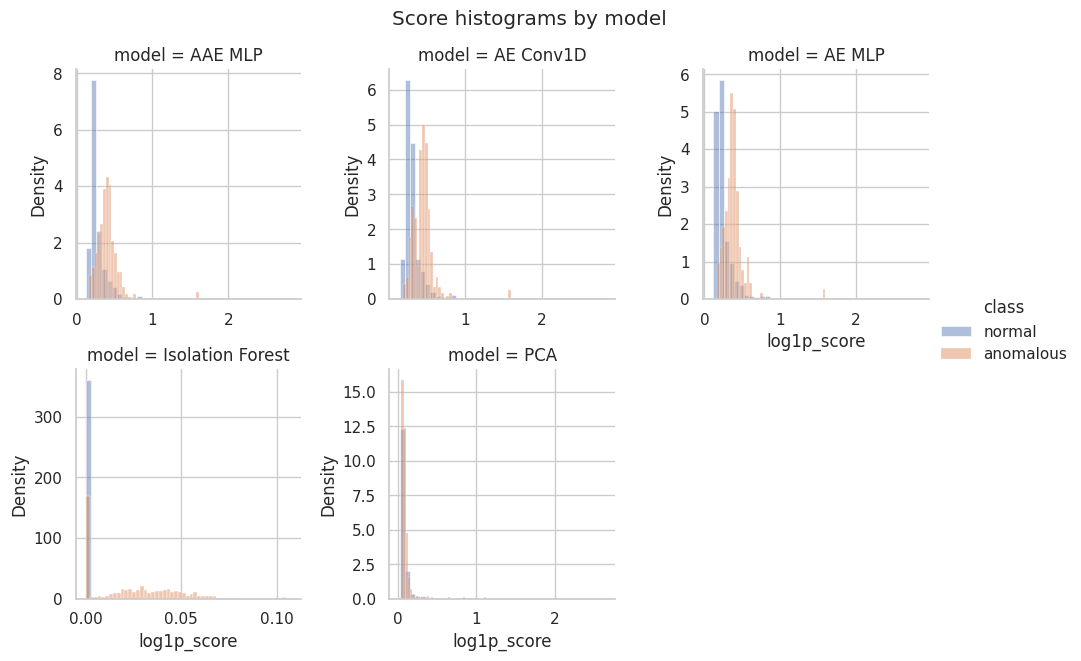

In [10]:
plot_scores = test_scores_all.copy()
plot_scores['log1p_score'] = np.log1p(np.maximum(plot_scores['score'], 0))
plot_scores['class'] = np.where(plot_scores.get('label', 0) == 1, 'anomalous', 'normal')

plt.figure(figsize=(11, 5))
ax = sns.violinplot(data=plot_scores, x='model', y='log1p_score', hue='class', split=True, inner='quartile', cut=0)
ax.set_title('Test score distribution by class')
ax.set_xlabel('')
ax.set_ylabel('log1p(score)')
ax.tick_params(axis='x', rotation=25)
save_current_fig('test_score_distribution_violin.png')
plt.show()

g = sns.FacetGrid(plot_scores, col='model', hue='class', col_wrap=3, height=3.2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='log1p_score', stat='density', bins=40, alpha=0.45)
g.add_legend()
g.fig.suptitle('Score histograms by model', y=1.03)
g.savefig(FIGURES_DIR / 'test_score_histograms_by_model.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Curve ROC e Precision-Recall da score salvati

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/test_roc_curves_combined.png


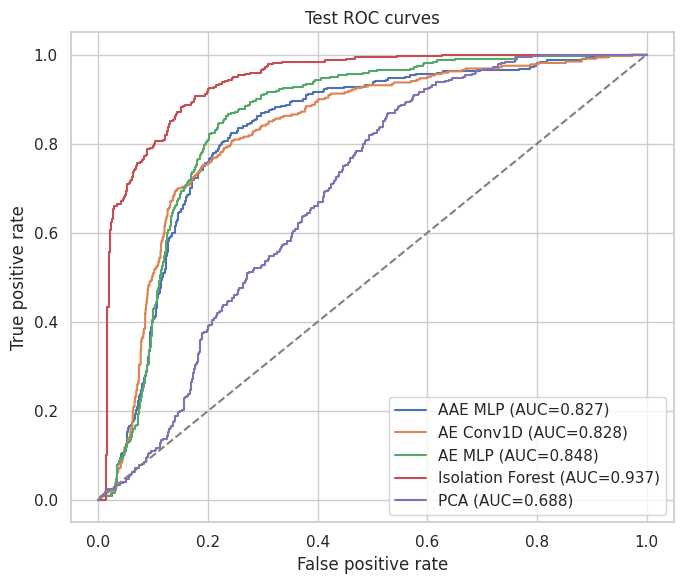

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/test_pr_curves_combined.png


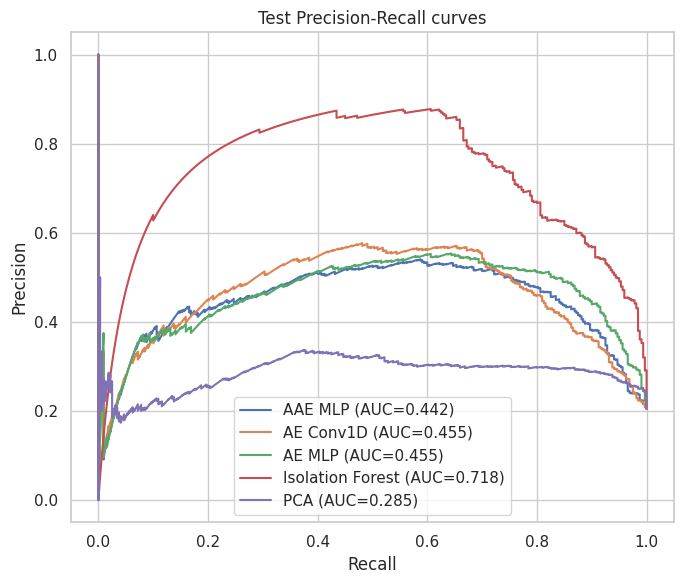

In [11]:
plt.figure(figsize=(7, 6))
for model_key, splits in scores.items():
    frame = splits.get('test')
    if frame is None or 'label' not in frame or frame['label'].nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(frame['label'], frame['score'])
    plt.plot(fpr, tpr, label=f"{model_label(model_key)} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Test ROC curves')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
save_current_fig('test_roc_curves_combined.png')
plt.show()

plt.figure(figsize=(7, 6))
for model_key, splits in scores.items():
    frame = splits.get('test')
    if frame is None or 'label' not in frame or frame['label'].nunique() < 2:
        continue
    precision, recall, _ = precision_recall_curve(frame['label'], frame['score'])
    plt.plot(recall, precision, label=f"{model_label(model_key)} (AUC={auc(recall, precision):.3f})")
plt.title('Test Precision-Recall curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
save_current_fig('test_pr_curves_combined.png')
plt.show()

## 10. Confusion matrix e profilo errori

error_type,TN,FP,FN,TP
model,,,,
AAE MLP,900,344,49,271
AE Conv1D,1052,192,95,225
AE MLP,925,319,39,281
Isolation Forest,1074,170,47,273
PCA,833,411,141,179


Saved: /content/drive/MyDrive/AM01/results/analysis/figures/window_outcomes_by_model.png


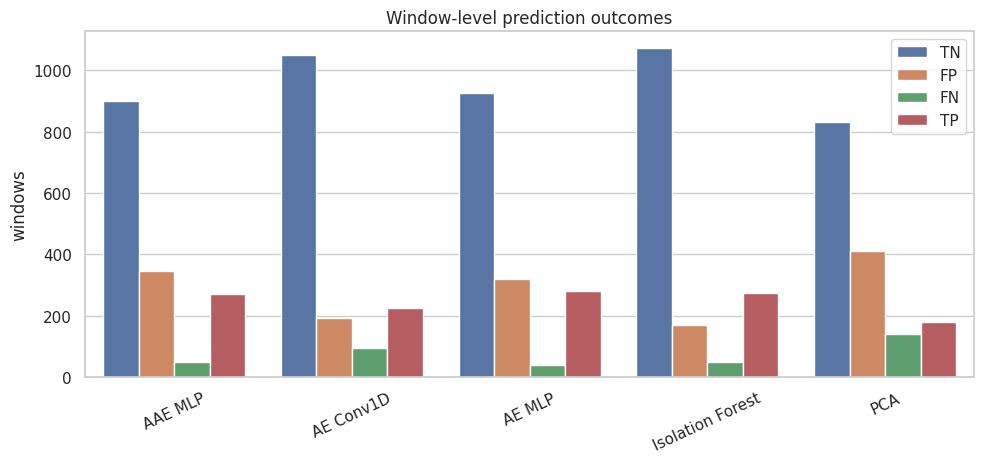

In [12]:
if 'error_type' in test_scores_all.columns:
    confusion_counts = test_scores_all.groupby(['model', 'error_type']).size().unstack(fill_value=0)
    confusion_counts = confusion_counts.reindex(columns=['TN', 'FP', 'FN', 'TP'], fill_value=0)
    confusion_counts.to_csv(TABLES_DIR / 'confusion_counts_by_model.csv')
    display(confusion_counts)

    confusion_long = confusion_counts.reset_index().melt(id_vars='model', var_name='type', value_name='windows')
    plt.figure(figsize=(10, 4.8))
    ax = sns.barplot(data=confusion_long, x='model', y='windows', hue='type')
    ax.set_title('Window-level prediction outcomes')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='')
    save_current_fig('window_outcomes_by_model.png')
    plt.show()

## 11. Falsi positivi e falsi negativi per run

Questa sezione individua failure cases da ispezionare nel report.

### Top false-positive runs

error_type,model,run_id,FP,TN,fp_rate,n_windows
1974,Isolation Forest,normal_seg_1967,18,0,1.000,18
198,AAE MLP,normal_seg_1022,7,0,1.000,7
725,AE Conv1D,normal_seg_1022,7,0,1.000,7
1252,AE MLP,normal_seg_1022,7,0,1.000,7
2306,PCA,normal_seg_1022,7,0,1.000,7
364,AAE MLP,normal_seg_1786,6,0,1.000,6
382,AAE MLP,normal_seg_1906,6,0,1.000,6
891,AE Conv1D,normal_seg_1786,6,0,1.000,6
909,AE Conv1D,normal_seg_1906,6,0,1.000,6
1418,AE MLP,normal_seg_1786,6,0,1.000,6


### Top false-negative runs

error_type,model,run_id,FN,TP,fn_rate,n_windows
2629,PCA,slow_seg_0279,6,2,0.750,8
1018,AE Conv1D,slow_seg_0143,5,0,1.000,5
2611,PCA,slow_seg_0200,5,0,1.000,5
2616,PCA,slow_seg_0221,5,0,1.000,5
2617,PCA,slow_seg_0222,5,0,1.000,5
2624,PCA,slow_seg_0263,5,0,1.000,5
2627,PCA,slow_seg_0274,5,0,1.000,5
2630,PCA,slow_seg_0284,5,0,1.000,5
2609,PCA,slow_seg_0198,5,2,0.714,7
2613,PCA,slow_seg_0213,5,2,0.714,7


Saved: /content/drive/MyDrive/AM01/results/analysis/figures/top_false_positive_runs.png


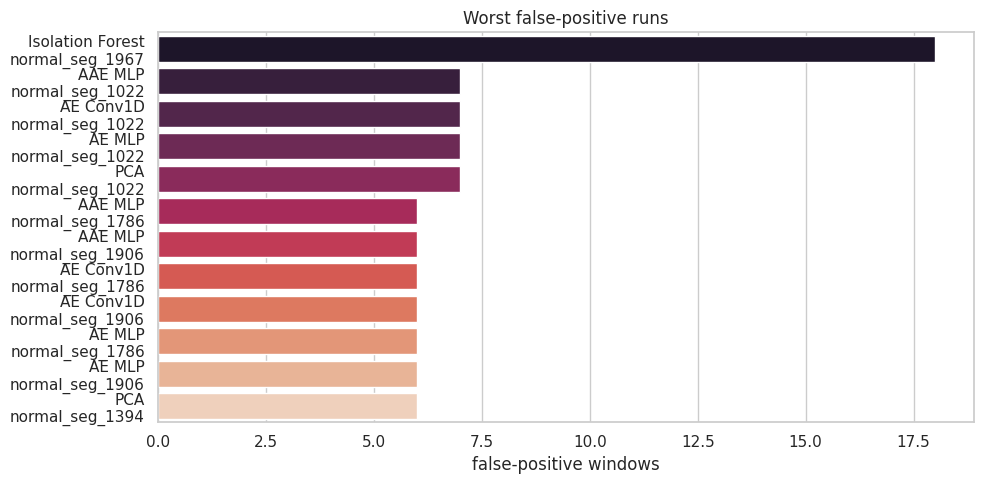

In [13]:
if 'error_type' in test_scores_all.columns:
    run_errors = (
        test_scores_all
        .groupby(['model', 'model_key', 'run_id', 'error_type'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for col in ['TN', 'FP', 'FN', 'TP']:
        if col not in run_errors:
            run_errors[col] = 0
    run_errors['n_windows'] = run_errors[['TN', 'FP', 'FN', 'TP']].sum(axis=1)
    run_errors['fp_rate'] = run_errors['FP'] / run_errors[['TN', 'FP']].sum(axis=1).replace(0, np.nan)
    run_errors['fn_rate'] = run_errors['FN'] / run_errors[['FN', 'TP']].sum(axis=1).replace(0, np.nan)
    run_errors.to_csv(TABLES_DIR / 'run_error_breakdown.csv', index=False)

    top_fp = run_errors.sort_values(['FP', 'fp_rate'], ascending=False).head(20)
    top_fn = run_errors.sort_values(['FN', 'fn_rate'], ascending=False).head(20)
    display(Markdown('### Top false-positive runs'))
    display(top_fp[['model', 'run_id', 'FP', 'TN', 'fp_rate', 'n_windows']].style.format({'fp_rate': '{:.3f}'}))
    display(Markdown('### Top false-negative runs'))
    display(top_fn[['model', 'run_id', 'FN', 'TP', 'fn_rate', 'n_windows']].style.format({'fn_rate': '{:.3f}'}))

    top_fp.to_csv(TABLES_DIR / 'top_false_positive_runs.csv', index=False)
    top_fn.to_csv(TABLES_DIR / 'top_false_negative_runs.csv', index=False)

    plt.figure(figsize=(10, 5))
    plot_top = top_fp.head(12).copy()
    plot_top['label'] = plot_top['model'] + '\n' + plot_top['run_id'].astype(str)
    ax = sns.barplot(data=plot_top, y='label', x='FP', palette='rocket')
    ax.set_title('Worst false-positive runs')
    ax.set_xlabel('false-positive windows')
    ax.set_ylabel('')
    save_current_fig('top_false_positive_runs.png')
    plt.show()

## 12. Timeline degli score

Scegli un run interessante. Di default il notebook usa il peggior falso positivo trovato sopra.

SELECTED_RUN_ID: normal_seg_1967
Saved: /content/drive/MyDrive/AM01/results/analysis/figures/timeline_run_normal_seg_1967.png


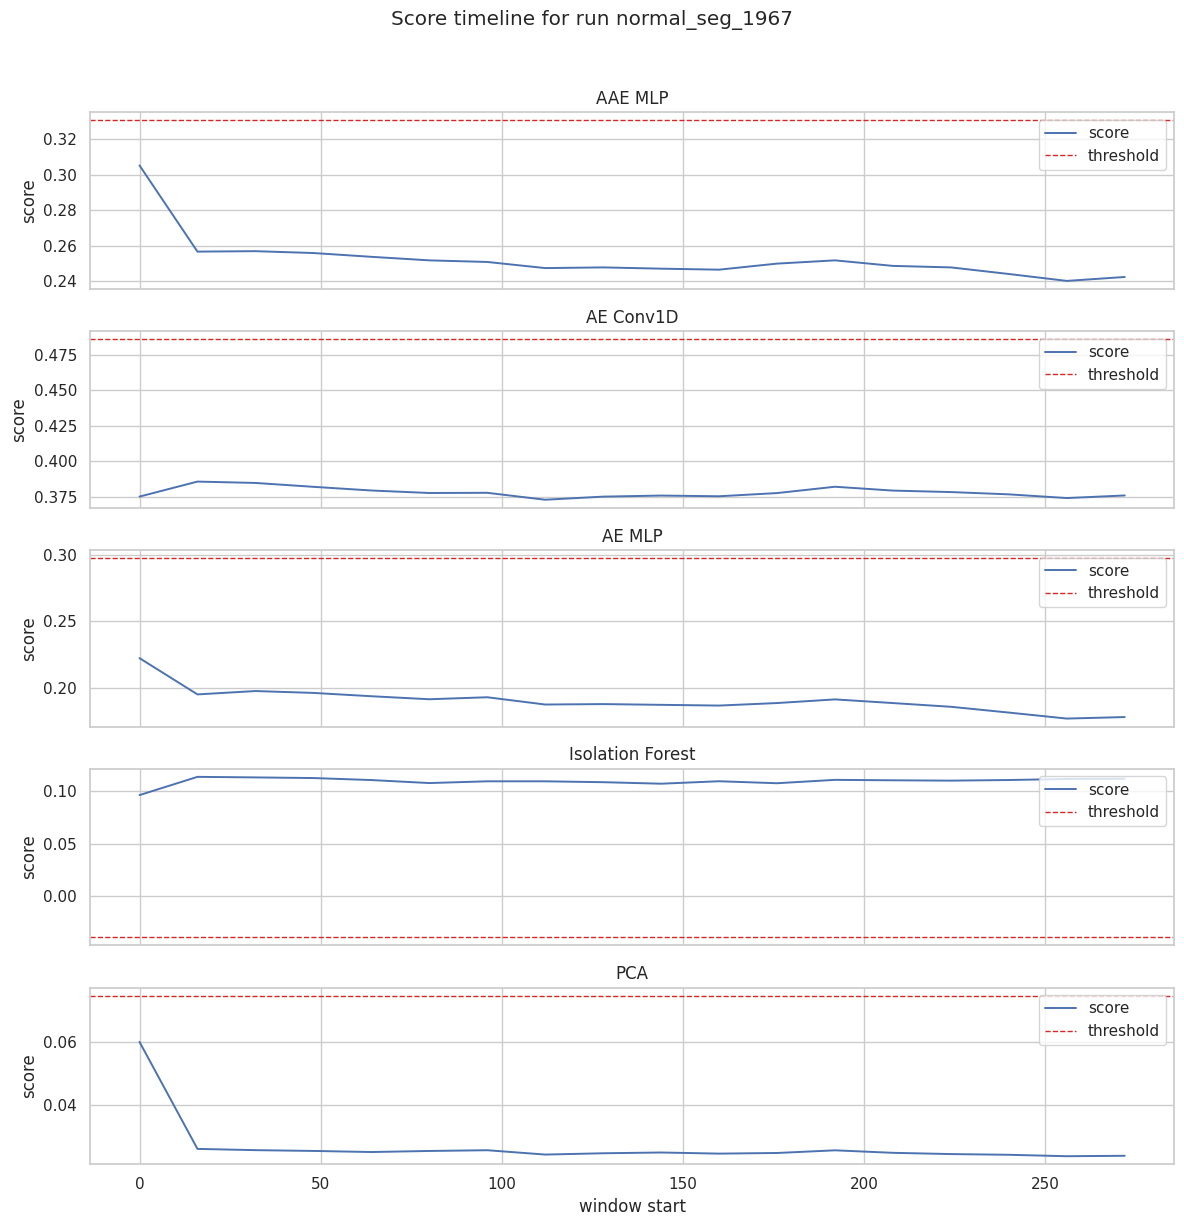

In [14]:
def plot_run_timeline(run_id: str, model_keys: list[str] | None = None, split: str = 'test'):
    if model_keys is None:
        model_keys = list(scores.keys())
    rows = []
    for model_key in model_keys:
        frame = scores.get(model_key, {}).get(split)
        if frame is None:
            continue
        part = frame[frame['run_id'].astype(str) == str(run_id)].copy()
        if not part.empty:
            rows.append(part)
    if not rows:
        print(f'Nessun dato trovato per run_id={run_id}')
        return
    data = pd.concat(rows, ignore_index=True)
    models = data['model'].unique()
    fig, axes = plt.subplots(len(models), 1, figsize=(12, max(3, 2.4 * len(models))), sharex=True)
    if len(models) == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        part = data[data['model'] == model].sort_values('start')
        ax.plot(part['start'], part['score'], linewidth=1.4, label='score')
        threshold = part['threshold'].iloc[0]
        ax.axhline(threshold, color='tab:red', linestyle='--', linewidth=1, label='threshold')
        if 'label' in part.columns:
            anomalous = part['label'].to_numpy() == 1
            if anomalous.any():
                ymin, ymax = ax.get_ylim()
                ax.fill_between(part['start'], ymin, ymax, where=anomalous, color='tab:orange', alpha=0.18, step='mid', label='anomaly')
        ax.set_title(model)
        ax.set_ylabel('score')
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('window start')
    fig.suptitle(f'Score timeline for run {run_id}', y=1.02)
    path = FIGURES_DIR / f'timeline_run_{run_id}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:', path)
    plt.show()


if 'run_errors' in globals() and not run_errors.empty:
    default_run = str(run_errors.sort_values(['FP', 'FN'], ascending=False).iloc[0]['run_id'])
else:
    default_run = str(test_scores_all['run_id'].iloc[0])

SELECTED_RUN_ID = default_run
print('SELECTED_RUN_ID:', SELECTED_RUN_ID)
plot_run_timeline(SELECTED_RUN_ID)

## 13. Correlazione degli score tra modelli

Se due modelli sbagliano sulle stesse finestre, gli score saranno correlati. Questo aiuta a capire se i modelli sono davvero complementari.

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/score_correlation_heatmap.png


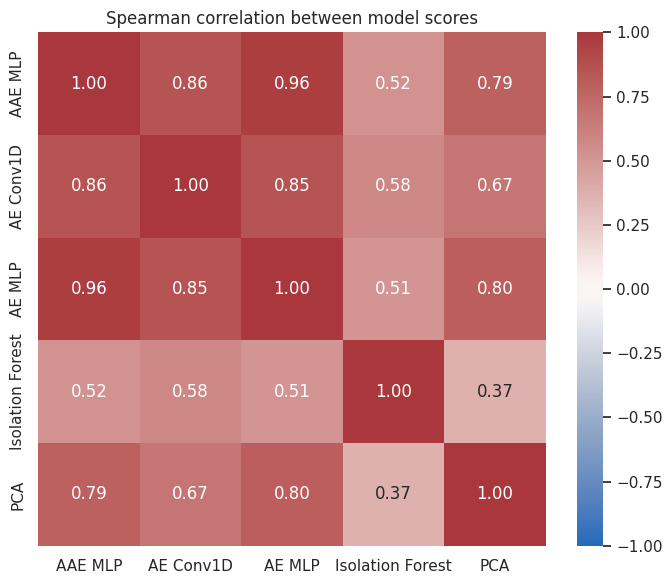

In [15]:
wide_parts = []
for model_key, splits in scores.items():
    frame = splits.get('test')
    if frame is None:
        continue
    wide_parts.append(frame[['run_id', 'start', 'score']].rename(columns={'score': model_label(model_key)}))

if wide_parts:
    wide = wide_parts[0]
    for part in wide_parts[1:]:
        wide = wide.merge(part, on=['run_id', 'start'], how='inner')
    score_cols = [c for c in wide.columns if c not in ['run_id', 'start']]
    corr = wide[score_cols].corr(method='spearman')
    corr.to_csv(TABLES_DIR / 'score_spearman_correlation.csv')
    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(corr, annot=True, cmap='vlag', vmin=-1, vmax=1, fmt='.2f')
    ax.set_title('Spearman correlation between model scores')
    save_current_fig('score_correlation_heatmap.png')
    plt.show()
else:
    print('Score wide table non disponibile.')

## 14. Training history dei modelli neurali

,model_key,model,epoch,train_loss,val_loss,discriminator_loss,adversarial_loss
0,aae_mlp,AAE MLP,1,0.831413,0.649570,1.276170,0.981384
1,aae_mlp,AAE MLP,2,0.634280,0.530118,1.196877,1.530865
2,aae_mlp,AAE MLP,3,0.563323,0.488879,1.229969,1.327138
3,aae_mlp,AAE MLP,4,0.533398,0.471731,1.203492,1.242137
4,aae_mlp,AAE MLP,5,0.518161,0.459969,1.241133,1.247714


Saved: /content/drive/MyDrive/AM01/results/analysis/figures/training_history_reconstruction.png


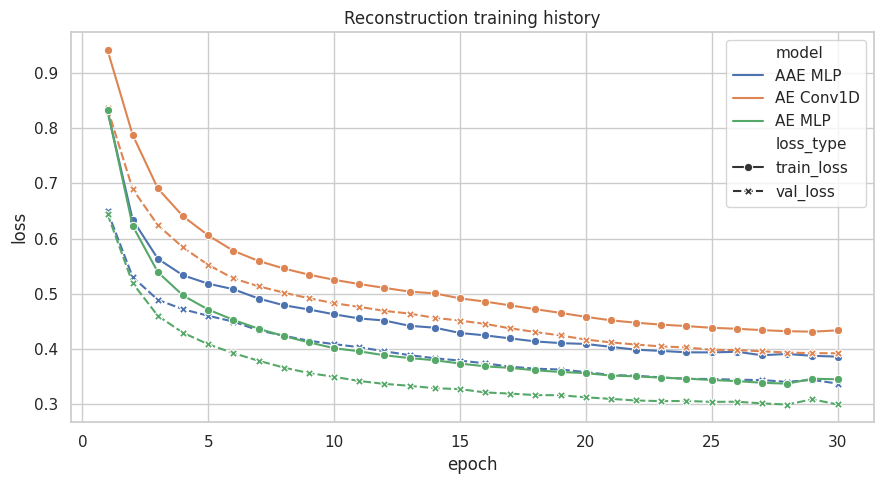

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/aae_adversarial_losses.png


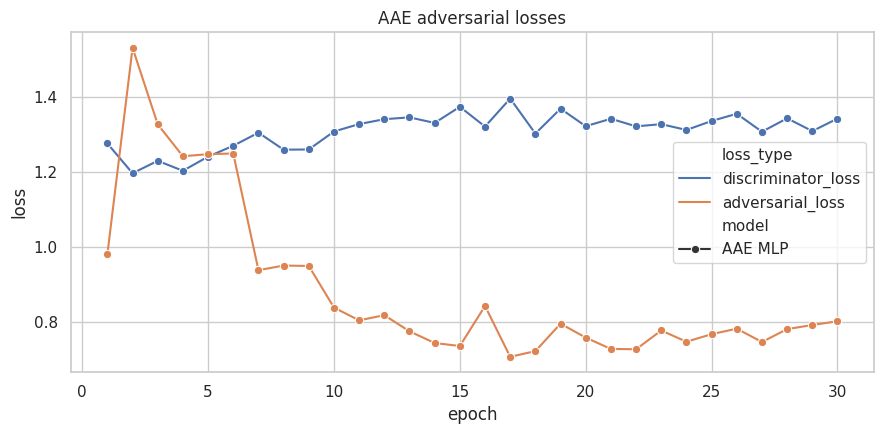

In [16]:
history_rows = []
for run_dir in run_dirs:
    path = run_dir / 'history.json'
    if not path.exists():
        continue
    key = model_key_from_dir(run_dir)
    hist = read_json(path)
    max_len = max(len(v) for v in hist.values() if isinstance(v, list))
    for epoch in range(max_len):
        row = {'model_key': key, 'model': model_label(key), 'epoch': epoch + 1}
        for metric, values in hist.items():
            if isinstance(values, list) and epoch < len(values):
                row[metric] = values[epoch]
        history_rows.append(row)

history_df = pd.DataFrame(history_rows)
if not history_df.empty:
    history_df.to_csv(TABLES_DIR / 'training_history.csv', index=False)
    display(history_df.head())
    plt.figure(figsize=(9, 5))
    hist_long = history_df.melt(id_vars=['model', 'epoch'], value_vars=[c for c in ['train_loss', 'val_loss'] if c in history_df], var_name='loss_type', value_name='loss')
    ax = sns.lineplot(data=hist_long, x='epoch', y='loss', hue='model', style='loss_type', markers=True)
    ax.set_title('Reconstruction training history')
    save_current_fig('training_history_reconstruction.png')
    plt.show()

    adv_cols = [c for c in ['discriminator_loss', 'adversarial_loss'] if c in history_df.columns and history_df[c].notna().any()]
    if adv_cols:
        plt.figure(figsize=(9, 4.5))
        adv_long = history_df.melt(id_vars=['model', 'epoch'], value_vars=adv_cols, var_name='loss_type', value_name='loss').dropna()
        ax = sns.lineplot(data=adv_long, x='epoch', y='loss', hue='loss_type', style='model', markers=True)
        ax.set_title('AAE adversarial losses')
        save_current_fig('aae_adversarial_losses.png')
        plt.show()
else:
    print('Nessun history.json trovato.')

## 15. Dataset audit e feature analysis

Se disponibili, questi file aiutano a spiegare outlier, feature quasi costanti e split.

Loaded dataset summary: `/content/drive/MyDrive/AM01/results/data_audit/dataset_summary.csv`

,run_id,n_rows,run_label,anomaly_fraction,source_file,action
0,normal_seg_0000,142,normal,0.0,normal,0.0
1,normal_seg_0001,108,normal,0.0,normal,1.0
2,normal_seg_0002,110,normal,0.0,normal,2.0
3,normal_seg_0003,110,normal,0.0,normal,1.0
4,normal_seg_0004,111,normal,0.0,normal,2.0


Saved: /content/drive/MyDrive/AM01/results/analysis/figures/dataset_runs_by_label.png


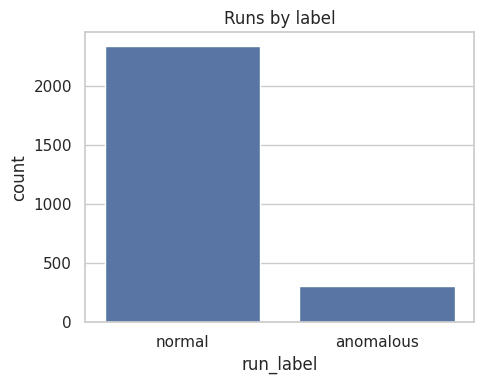

Saved: /content/drive/MyDrive/AM01/results/analysis/figures/dataset_run_length_distribution.png


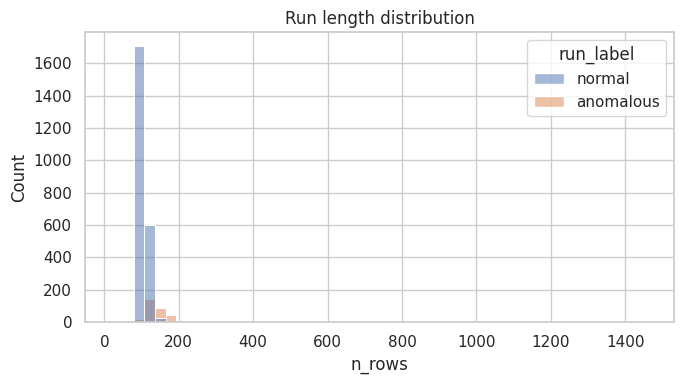

Loaded feature summary: `/content/drive/MyDrive/AM01/results/data_audit/feature_summary.csv`

### Near-constant features

,feature,std,range
29,sensor_id2_temp,0.000000,0.000000
62,sensor_id5_temp,0.000000,0.000000
84,sensor_id7_temp,0.000000,0.000000
73,sensor_id6_temp,0.000000,0.000000
76,sensor_id7_AccZ,0.011665,0.379395
75,sensor_id7_AccY,0.017275,0.556152
39,sensor_id3_q4,0.024063,0.443569
38,sensor_id3_q3,0.024821,0.290583
5,machine_nameKuka Robot_power_factor,0.025756,0.166530
2,machine_nameKuka Robot_frequency,0.032379,0.195313


### Widest-range features

,feature,std,range,min,max
13,sensor_id1_GyroZ,49.911,3998.413,-1998.901,1999.512
12,sensor_id1_GyroY,44.086,3968.872,-1999.878,1968.994
11,sensor_id1_GyroX,29.025,3853.333,-1997.437,1855.896
45,sensor_id4_GyroY,26.744,3083.313,-1869.812,1213.501
44,sensor_id4_GyroX,20.162,1943.176,-1859.436,83.740
46,sensor_id4_GyroZ,21.322,1943.115,-656.677,1286.438
35,sensor_id3_GyroZ,13.989,796.082,-74.524,721.558
33,sensor_id3_GyroX,7.313,763.611,-42.053,721.558
34,sensor_id3_GyroY,6.024,761.536,-39.978,721.558
18,sensor_id1_temp,7.116,634.880,-326.920,307.960


In [17]:
audit_summary_path = RESULTS_ROOT / 'data_audit' / 'dataset_summary.csv'
feature_summary_path = RESULTS_ROOT / 'data_audit' / 'feature_summary.csv'
if not audit_summary_path.exists():
    candidates = list(RESULTS_ROOT.rglob('dataset_summary.csv'))
    audit_summary_path = candidates[0] if candidates else audit_summary_path
if not feature_summary_path.exists():
    candidates = list(RESULTS_ROOT.rglob('feature_summary.csv'))
    feature_summary_path = candidates[0] if candidates else feature_summary_path

if audit_summary_path.exists():
    dataset_summary = pd.read_csv(audit_summary_path)
    display(Markdown(f'Loaded dataset summary: `{audit_summary_path}`'))
    compact_cols = [c for c in ['run_id', 'n_rows', 'run_label', 'anomaly_fraction', 'source_file', 'action'] if c in dataset_summary.columns]
    display(dataset_summary[compact_cols].head())
    if 'run_label' in dataset_summary:
        plt.figure(figsize=(5, 4))
        ax = sns.countplot(data=dataset_summary, x='run_label')
        ax.set_title('Runs by label')
        save_current_fig('dataset_runs_by_label.png')
        plt.show()
    if 'n_rows' in dataset_summary:
        plt.figure(figsize=(7, 4))
        ax = sns.histplot(data=dataset_summary, x='n_rows', hue='run_label' if 'run_label' in dataset_summary else None, bins=50)
        ax.set_title('Run length distribution')
        save_current_fig('dataset_run_length_distribution.png')
        plt.show()
else:
    print('dataset_summary.csv non trovato.')

if feature_summary_path.exists():
    feature_summary = pd.read_csv(feature_summary_path)
    display(Markdown(f'Loaded feature summary: `{feature_summary_path}`'))
    if {'feature', 'std', 'min', 'max'}.issubset(feature_summary.columns):
        feature_summary['range'] = feature_summary['max'] - feature_summary['min']
        near_constant = feature_summary.sort_values('std').head(12)
        widest = feature_summary.sort_values('range', ascending=False).head(12)
        near_constant.to_csv(TABLES_DIR / 'near_constant_features.csv', index=False)
        widest.to_csv(TABLES_DIR / 'widest_range_features.csv', index=False)
        display(Markdown('### Near-constant features'))
        display(near_constant[['feature', 'std', 'range']].style.format(precision=6))
        display(Markdown('### Widest-range features'))
        display(widest[['feature', 'std', 'range', 'min', 'max']].style.format(precision=3))
else:
    print('feature_summary.csv non trovato.')

## 16. Split e processed arrays

Controllo rapido di dimensioni, NaN/Inf e range nei file `.npz` processati.

In [18]:
processed_candidates = [DRIVE_ROOT / 'data' / 'processed' / 'kuka_default']
processed_candidates += [p.parent for p in RESULTS_ROOT.rglob('processed_train.npz')]
processed_dir = next((p for p in processed_candidates if (p / 'processed_train.npz').exists()), None)

if processed_dir is not None:
    rows = []
    for split in ['train', 'val', 'test']:
        path = processed_dir / f'processed_{split}.npz'
        if not path.exists():
            continue
        arr = np.load(path, allow_pickle=True)
        X = arr['X']
        y = arr['y'] if bool(arr['has_labels']) else None
        rows.append({
            'split': split,
            'shape': str(X.shape),
            'windows': X.shape[0],
            'window_length': X.shape[1],
            'channels': X.shape[2],
            'anomalous_windows': int(y.sum()) if y is not None and len(y) else None,
            'nan_count': int(np.isnan(X).sum()),
            'inf_count': int(np.isinf(X).sum()),
            'min': float(np.nanmin(X)),
            'max': float(np.nanmax(X)),
            'mean': float(np.nanmean(X)),
            'std': float(np.nanstd(X)),
        })
    processed_stats = pd.DataFrame(rows)
    processed_stats.to_csv(TABLES_DIR / 'processed_array_stats.csv', index=False)
    display(Markdown(f'Processed directory: `{processed_dir}`'))
    display(processed_stats.style.format(precision=3))
else:
    print('Nessuna directory processed trovata.')

Processed directory: `/content/drive/MyDrive/AM01/data/processed/kuka_default`

,split,shape,windows,window_length,channels,anomalous_windows,nan_count,inf_count,min,max,mean,std
0,train,"(4725, 64, 85)",4725,64,85,924,0,0,-375.195,108.301,-0.002,0.973
1,val,"(1537, 64, 85)",1537,64,85,315,0,0,-87.539,59.735,-0.007,0.956
2,test,"(1564, 64, 85)",1564,64,85,320,0,0,-100.814,125.028,-0.005,0.975


## 17. Insight automatici

Questa cella produce un breve riassunto testuale, utile come base per la discussione del report.

In [19]:
notes = []
if 'test_f1' in metrics_df:
    best = metrics_df.loc[metrics_df['test_f1'].idxmax()]
    notes.append(f"Best F1 model: {best['model']} (F1={best['test_f1']:.3f}).")
if 'test_pr_auc' in metrics_df:
    best = metrics_df.loc[metrics_df['test_pr_auc'].idxmax()]
    notes.append(f"Best PR-AUC model: {best['model']} (PR-AUC={best['test_pr_auc']:.3f}).")
if set(['ae_mlp', 'aae_mlp']).issubset(set(metrics_df['model_key'])) and 'test_f1' in metrics_df:
    ae = metrics_df[metrics_df['model_key'] == 'ae_mlp'].iloc[0]
    aae = metrics_df[metrics_df['model_key'] == 'aae_mlp'].iloc[0]
    delta_f1 = aae['test_f1'] - ae['test_f1']
    delta_pr = aae.get('test_pr_auc', np.nan) - ae.get('test_pr_auc', np.nan)
    if delta_f1 > 0:
        notes.append(f"AAE improves AE MLP F1 by {delta_f1:.3f}; check if this is stable across seeds.")
    else:
        notes.append(f"AAE does not improve AE MLP F1 in the current run (delta={delta_f1:.3f}).")
    if not np.isnan(delta_pr):
        notes.append(f"AAE - AE PR-AUC delta: {delta_pr:.3f}.")
if 'test_false_alarms_per_run' in metrics_df:
    best = metrics_df.loc[metrics_df['test_false_alarms_per_run'].idxmin()]
    notes.append(f"Lowest false alarms/run: {best['model']} ({best['test_false_alarms_per_run']:.3f}).")
if 'run_errors' in globals() and not run_errors.empty:
    worst = run_errors.sort_values(['FP', 'FN'], ascending=False).iloc[0]
    notes.append(f"Most problematic run by window errors: {worst['run_id']} for {worst['model']}.")

notes_path = ANALYSIS_DIR / 'auto_insights.md'
notes_path.write_text('\n'.join(f'- {note}' for note in notes), encoding='utf-8')
display(Markdown('## Auto-generated insights\n' + '\n'.join(f'- {note}' for note in notes)))
print('Saved:', notes_path)

## Auto-generated insights
- Best F1 model: Isolation Forest (F1=0.716).
- Best PR-AUC model: Isolation Forest (PR-AUC=0.720).
- AAE does not improve AE MLP F1 in the current run (delta=-0.031).
- AAE - AE PR-AUC delta: -0.013.
- Lowest false alarms/run: Isolation Forest (0.150).
- Most problematic run by window errors: normal_seg_1967 for Isolation Forest.

Saved: /content/drive/MyDrive/AM01/results/analysis/auto_insights.md


## 18. Manifest artefatti generati

Questa lista indica cosa portare nel report o nella presentazione.

In [20]:
generated = sorted([p for p in ANALYSIS_DIR.rglob('*') if p.is_file()])
display(pd.DataFrame({'artifact': [str(p.relative_to(ANALYSIS_DIR)) for p in generated]}))

,artifact
0,auto_insights.md
1,figures/aae_adversarial_losses.png
2,figures/aae_minus_ae_deltas.png
3,figures/bar_test_f1.png
4,figures/bar_test_false_alarms_per_run.png
5,figures/bar_test_pr_auc.png
6,figures/bar_test_roc_auc.png
7,figures/dataset_run_length_distribution.png
8,figures/dataset_runs_by_label.png
9,figures/metric_profile_by_model.png
